In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [2]:
# Loading dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Exploratory Data Analysis

In [3]:
print(df.head(5))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print(df.shape)

(7043, 21)


In [6]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [7]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
df.drop("customerID", axis=1, inplace=True)

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [33]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


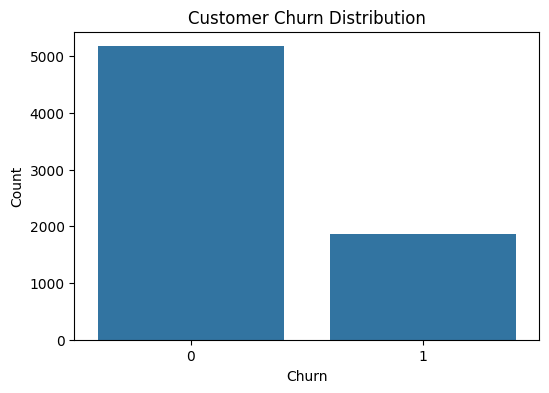

In [32]:
# Churn Distribution Chart
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

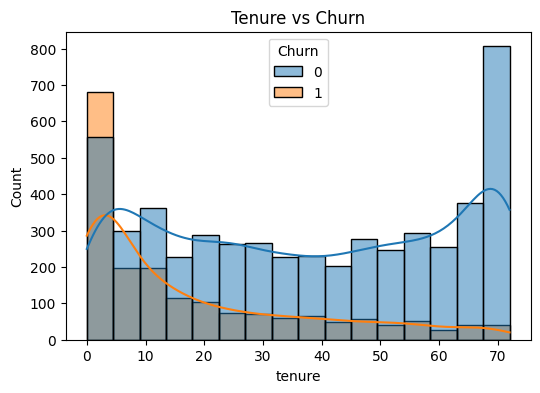

In [38]:
# Tenure vs Churn
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True)
plt.title("Tenure vs Churn")
plt.show()

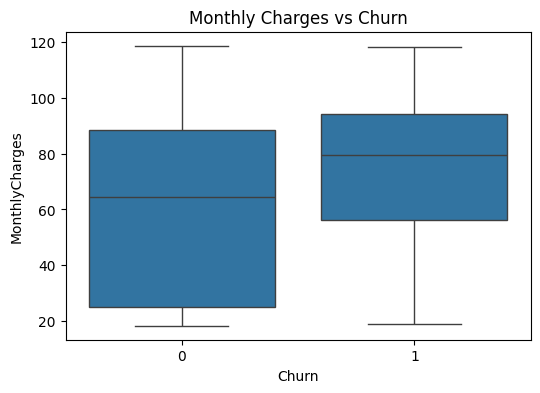

In [39]:
# Monthly charges vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

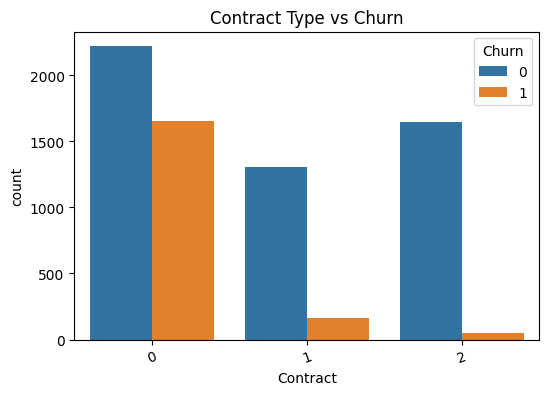

In [40]:
# Contract type vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

In [10]:
# Label encoding categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [11]:
# Splitting feature and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42)

In [13]:
# Feature scaling (Standardization) 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
# Creating models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

In [15]:
# Train and evaluate model
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results.append([name, accuracy])
    print("Model: ",name)
    print("Accuracy:", accuracy)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Model:  Logistic Regression
Accuracy: 0.815471965933286

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409

Model:  Random Forest
Accuracy: 0.7906316536550745

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.65      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

Model:  SVM
Accuracy: 0.8069552874378992

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.87      1036
           1     

In [16]:
# Compare accuracy of models
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.815472
1        Random Forest  0.790632
2                  SVM  0.806955
3              XGBoost  0.794180


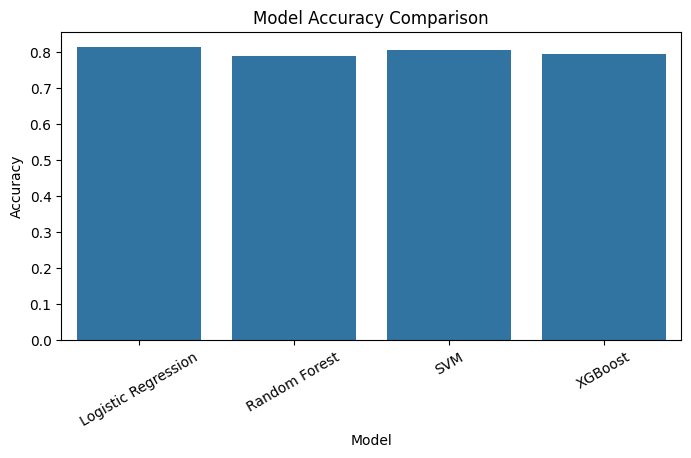

In [17]:
# Plotting accuracy comparison
plt.figure(figsize=(8,4))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.show()

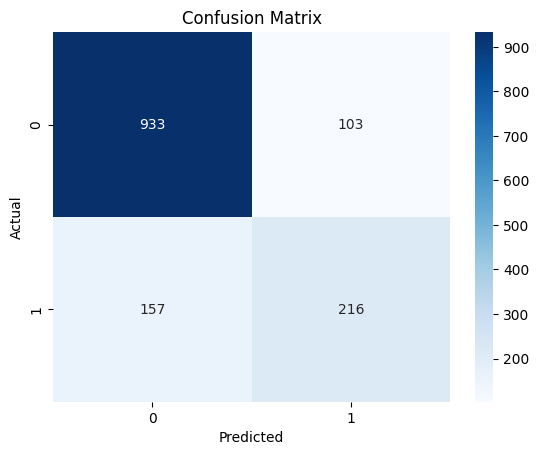

In [18]:
# Confusion Matrix 
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

             Feature  Coefficient
17    MonthlyCharges     0.671275
18      TotalCharges     0.598536
15  PaperlessBilling     0.175604
7    InternetService     0.173471
6      MultipleLines     0.066369
1      SeniorCitizen     0.066356
16     PaymentMethod     0.062140
2            Partner     0.033417
13   StreamingMovies     0.030999
12       StreamingTV    -0.012834


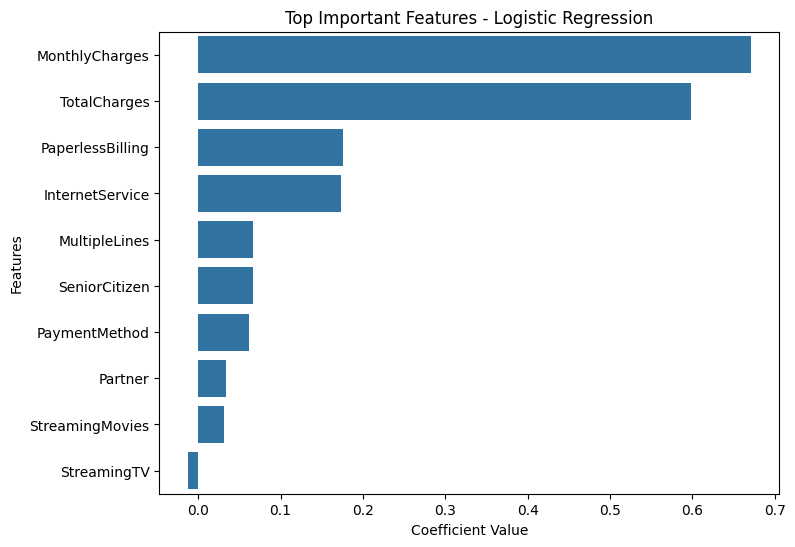

In [19]:
# Feature Importance - Logistic Regression
coefficients = lr.coef_[0]
feature_importance = pd.DataFrame({'Feature': X.columns,'Coefficient': coefficients})
feature_importance = feature_importance.sort_values(by='Coefficient',ascending=False)
print(feature_importance.head(10))
plt.figure(figsize=(8,6))
sns.barplot(x='Coefficient',y='Feature',data=feature_importance.head(10))
plt.title('Top Important Features - Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

In [20]:
# Example 1 : New customer data for our Telecom Churn Model
new_customer = pd.DataFrame({'gender': [0],'SeniorCitizen': [0],'Partner': [1],'Dependents': [0],'tenure': [5],
    'PhoneService': [1],'MultipleLines': [0],'InternetService': [1],'OnlineSecurity': [0],'OnlineBackup': [1],
    'DeviceProtection': [0],'TechSupport': [0],'StreamingTV': [1],'StreamingMovies': [1],'Contract': [0],'PaperlessBilling': [1],
    'PaymentMethod': [2],'MonthlyCharges': [85],'TotalCharges': [425]
})
new_customer_scaled = scaler.transform(new_customer)
prediction = lr.predict(new_customer_scaled)
if prediction[0] == 1:
    print("Customer is likely to CHURN")
else:
    print("Customer is likely to STAY")
probability = lr.predict_proba(new_customer_scaled)
print("Stay Probability:", probability[0][0])
print("Churn Probability:", probability[0][1])

Customer is likely to CHURN
Stay Probability: 0.3001736621309866
Churn Probability: 0.6998263378690134


In [21]:
# Example 2 : New customer data for a customer who will likely NOT churn
new_customer = pd.DataFrame({'gender': [1],'SeniorCitizen': [0],'Partner': [1],'Dependents': [1],'tenure': [60],
    'PhoneService': [1],'MultipleLines': [1],'InternetService': [0],'OnlineSecurity': [1],'OnlineBackup': [1],
    'DeviceProtection': [1],'TechSupport': [1],'StreamingTV': [0],'StreamingMovies': [0],'Contract': [2],'PaperlessBilling': [0],
    'PaymentMethod': [1],'MonthlyCharges': [45],'TotalCharges': [2700]
})
new_customer_scaled = scaler.transform(new_customer)
prediction = lr.predict(new_customer_scaled)
if prediction[0] == 1:
    print("Customer is likely to CHURN")
else:
    print("Customer is likely to STAY")
probability = lr.predict_proba(new_customer_scaled)
print("Stay Probability:", probability[0][0])
print("Churn Probability:", probability[0][1])

Customer is likely to STAY
Stay Probability: 0.9950953611603968
Churn Probability: 0.004904638839603259


In [28]:
# Saving the Model
import pickle
pickle.dump(lr, open("customer_churn_model.pkl", "wb"))
print ("File saved successfully")

File saved successfully


In [29]:
# Saving Label encoded data
pickle.dump(le, open("Label_encoded_model.pkl", "wb"))
print("File saved successfully")

File saved successfully
